# Submission 1: Your Model, Your Beam
### ME 323 Module 1

<img src="https://raw.githubusercontent.com/andrewvoss8-boop/core-me-data-science-activities-public/main/me323/Module1_drafts/figures/I_beam_dimensions.jpg" alt="I-beam dimensions" width="220">

Both common class designs have been queried. The scoreboard so far:

| design | (b, H_web) | predicted | returned strength and str/w on estimated-mass basis |
|---|---|---|---|
| equation-query beam from Pre-lab 1 | (1.10, 13.25) | 48.7 N/g | **37.48 N/g** (475.7 N) |
| locked GP-query beam from Pre-lab 2, MUI ψ=1 | (1.00, 13.39) | 36.7 N/g | **36.65 N/g** (445.8 N) |

The equation beam beat the 15-beam handout best of 36.88 N/g and is the best
of all 17. The GP beam probed the b = 1.0 edge of the newly opened box and
came back at 36.65 N/g — below the handout best, and close to what the model
expected there. Relative to their own predictions, the equation result came
in 23.0% low and the GP result just 0.0% below its 36.7 N/g prediction. Sit
with that pair of facts: the winning beam came from the prediction that
missed by 23.0%, while the nearly calibrated prediction described a beam not
worth building. A model can be honest about a mediocre region and still lose
to an overconfident one that happened to point somewhere better. One test
settles less than it seems to.

Both returned strengths came from the staff ground truth model — fit to the
prior test campaign, standing in for the testing machine — so nothing has
been printed yet. That changes here: fold both query results into the data,
build a model your way, and commit to a third design, the beam your group will
actually print and break. Do not call either common query beam your
Submission 1 design unless you deliberately choose those coordinates. The
final answer is a decision defended in the memo.

## Your knobs

This notebook hands you a working pipeline, but every modeling decision in it
is a variable you set: an assumption that goes into the model, not a setting
with a known right answer. The full dashboard:

| knob | variable (where) | options | the assumption you are making |
|---|---|---|---|
| model architecture | `CHOICE` (section 3) | `"A plain"` / `"B strength"` / `"C features"` / `"D residual"` | how much physics the model gets, and what quantity it learns — section 2 |
| prediction target | comes with the lane | str/w directly (lanes A, C, D) or raw strength ÷ mass (lane B) | which quantity is the smoother, easier thing to learn — section 2 |
| kernel | `KERNEL` (section 3) | `"RBF"` / `"Matern"` | how smooth the true strength surface is — section 3 |
| assumed noise | `NOISE_PCT` (section 3) | any percent; class default 3, pooled campaign repeats ≈ 4.4 (Pre-lab 2 section 4) | how much of beam-to-beam scatter is repeatability rather than real shape — section 3 |
| acquisition rule | `ACQ` (section 4) | `"MUI"` / `"EI"` | how predicted value and uncertainty combine into one pick — section 4 |
| explore vs exploit | `psi` (section 4, MUI only) | 0 = pure exploit; larger = more explore | how much a *chance* at a better beam is worth against a safe, good one — section 4 |

Two kinds of knobs, two ways to choose. Architecture and kernel make claims
the data can score, and the leave-one-out table in section 2 is their referee. Noise
and ψ make claims the data *cannot* score: no table can tell you the rig's
repeatability or how much risk your group should carry. Those you defend in
the memo with physical reasoning and stated values.

One more thing, since this module keeps saying there is no right answer: that
is a claim about the knobs, not about the grade. The grade follows the
defense, not the distance from the defaults — a defended default recipe
outscores an arbitrary exotic one.

**Which of these are really yours?** Not all six knobs carry the same weight.
Two are load-bearing decisions your group owns: the **lane** (how physics and
data combine — the module's central modeling question) and the **risk
posture** (`ACQ` plus its dial — how aggressively you chase predicted
performance versus uncertainty). The others — kernel, noise, target scale —
are assumptions you **stress-test**: after you commit to coordinates, check
whether they survive the kernel swap and the 1/3/10% noise refits, and report
what you find. "Our exact optimum moves under reasonable assumptions, but
every defensible model points at this neighborhood, so we chose a printable
point inside the stable region" is a stronger engineering conclusion than any
single recipe. And if your pick does *not* survive — say so: an unstable
recommendation is exactly when buying information beats chasing the current
maximum, and a memo that argues that earns its credit.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

# Fixed geometry (you choose b and H_web; everything else is set)
B, TH, L = 10.0, 18.0, 150.0     # flange width, total height, test span (mm)
LP = 172.0                        # printed length (mm); overhangs the 150 mm span
KMASS = 0.2045                    # g/mm^2: mass per unit cross-section area at 172 mm

# Handbook starting values — Pre-lab 1 calibrates the three marked ones
SY = 76e6                         # Pa, PLA strength                 (calibrated)
K_LTB = 0.33                      # fixture effective-length factor  (calibrated)
TAU_I = 43.9e6                    # printed-interface shear strength (Pa) — starting
                                  # guess = bulk yield / sqrt(3)     (calibrated)
E, G = 2.5e9, 2.5e9 / 2.6         # Young's / shear modulus (Pa) — fixed
C1, C2 = 1.35, 0.55               # LTB moment-gradient / load-height factors
URL = ("https://raw.githubusercontent.com/andrewvoss8-boop/"
       "core-me-data-science-activities-public/main/data/student_beams_B10_L150.csv")
try:
    df = pd.read_csv(URL); print("loaded from GitHub")
except Exception:
    try:
        df = pd.read_csv("student_beams_B10_L150.csv"); print("loaded local copy")
    except FileNotFoundError as e:
        raise FileNotFoundError(
            "no internet and no local copy -- download student_beams_B10_L150.csv "
            "from the course page into this notebook's folder and rerun") from e
df = df.rename(columns={"b_mm": "b", "H_web_mm": "H"})

def estimated_mass_g(b, H):
    A = b * H + B * (TH - H)      # cross-section area, mm^2
    return KMASS * A              # grams
df["mass_est_g"] = estimated_mass_g(df.b, df.H)
df["mass_delta_g"] = df.weight_g - df.mass_est_g
df["mass_delta_pct"] = 100*df.mass_delta_g/df.mass_est_g
print(len(df), "tested beams")

new = pd.DataFrame([
    dict(beam_id=16, b=1.10, H=13.25, strength_N=475.7,
         failure_note="equation-query result; observed morphology not supplied"),
    dict(beam_id=17, b=1.00, H=13.39, strength_N=445.8,
         failure_note="locked-GP-query result; observed morphology not supplied"),
])
new["weight_g"] = np.nan
new["mass_est_g"] = estimated_mass_g(new.b, new.H)
df = pd.concat([df, new], ignore_index=True)
df["str_to_weight"] = df.strength_N / df.mass_est_g
print(len(df), "beams. best observed:", round(df.str_to_weight.max(), 2), "N/g")
pd.set_option("display.max_colwidth", None)
print("\nFailure-note evidence available to the design decision:")
print(df[["beam_id", "b", "H", "failure_note"]].to_string(index=False))

loaded from GitHub
15 tested beams
17 beams. best observed: 37.47 N/g

Failure-note evidence available to the design decision:
 beam_id    b     H                                                                                                                                   failure_note
       1 7.00 16.00                                                                                       Complete vertical fracture across the center of the beam
       2 7.00 10.50                                                                                       Complete vertical fracture across the center of the beam
       3 4.85 14.40                                                               Vertical fracture on the bottom of the beam, but not completely through the beam
       4 3.25 15.10                                                               Vertical fracture on the bottom of the beam, but not completely through the beam
       5 3.55  7.50                                       

## 1. The calibrated physics (carried over from Pre-lab 1)

Provided complete this time, with the class calibration values baked in.

In [2]:
def section_props(b, H):
    """I-section properties. b, H in mm; everything returned in METERS/SI."""
    tf = (TH - H) / 2.0
    b_, h_, B_, tf_ = b/1e3, H/1e3, B/1e3, tf/1e3
    c = (TH/1e3) / 2
    Ix = (b_*h_**3)/12 + 2*((B_*tf_**3)/12 + B_*tf_*(h_/2 + tf_/2)**2)
    Iy = (h_*b_**3)/12 + 2*(tf_*B_**3)/12
    def J_rect(x, y):
        short, long = min(x, y), max(x, y)
        r = short/long
        beta = 1 - 0.63*r + 0.052*r**5
        return (1/3)*beta*long*short**3
    J = J_rect(b_, h_) + 2*J_rect(tf_, B_)
    Cw = Iy*(h_ + tf_)**2/4
    return dict(Ix=Ix, Iy=Iy, J=J, Cw=Cw, c=c,
                b=b_, h=h_, tf=tf_, B=B_)

def P_bend(p, sy):
    return 4*sy*p["Ix"] / (p["c"] * L/1e3)
def P_LTB(p, sy, k):
    My = sy*p["Ix"]/p["c"]
    Lb, zg = k*L/1e3, p["c"]
    R = p["Cw"]/p["Iy"] + (Lb**2*G*p["J"])/(np.pi**2*E*p["Iy"]) + (C2*zg)**2
    Mcr = C1*np.pi**2*E*p["Iy"]/Lb**2 * (np.sqrt(R) - C2*zg)
    return 4*min(My, Mcr)/(L/1e3)
def Q_flange(p):
    return p["B"]*p["tf"]*(p["h"]/2 + p["tf"]/2)
def P_sep(p, tau_i):
    """Flange-web separation: shear flow vs strength along the printed layer lines."""
    return 2*tau_i*p["Ix"]*p["b"]/Q_flange(p)
def capacity(b, H, sy, k, tau_i):
    """Class model (2026-07-15): plain minimum of the three mode capacities."""
    p = section_props(b, H)
    return min(P_bend(p, sy), P_sep(p, tau_i), P_LTB(p, sy, k))
def gov_mode(b, H, sy, k, tau_i):
    """Dominant pure-mode proxy, not an observed failure-mechanism label."""
    p = section_props(b, H)
    Pb, Ps, Pl = P_bend(p, sy), P_sep(p, tau_i), P_LTB(p, sy, k)
    return "separation" if Ps < min(Pb, Pl) else (
        "LTB" if Pl < 0.999*Pb else "bend")

SY_CAL, K_CAL, TAU_CAL = 6.683e+07, 0.377, 1.676e+07   # your Pre-lab 1 calibration
print("calibrated capacity(2,12) =", round(capacity(2, 12, SY_CAL, K_CAL, TAU_CAL), 1), "N")

calibrated capacity(2,12) = 734.2 N


## 2. Pick a lane: four ways to model the same 17 beams

"Model architecture" here means two choices at once: what the GP sees, and
what quantity it learns.

| lane | what the GP sees | what it predicts |
|---|---|---|
| **A — plain (vanilla GP)** | (b, H_web) | log str/w — the Pre-lab 2 model |
| **B — strength target** | (b, H_web) | log strength; divide by mass afterwards |
| **C — physics features** | (b, H_web, log P_phys, P_LTB/P_bend) | log str/w |
| **D — residual** | (b, H_web) | log(measured / P_phys) — physics first, GP corrects |

What each lane assumes:

- **A — plain (vanilla GP).** A pure pattern-matcher: str/w is a smooth
  function of the two geometry numbers and 17 points are enough to learn it.
  No physics at all — which also means no physics *errors*. Between data
  points it interpolates; far from data it drifts back toward the mean and
  its error bars balloon. That ballooning is honest, and it is also all the
  guidance you get out there.
- **B — strength target.** The same vanilla GP, but it learns raw newtons and
  you divide by estimated mass afterwards. Worth trying if you believe raw
  strength is the smoother surface. The catch: a small percentage error on a
  900 N prediction becomes a large N/g error once you divide by a light
  beam's mass. The LOO table shows how that gamble went here.
- **C — physics features.** The GP still learns str/w, but you hand it two
  extra inputs computed from the calibrated equations: the physics capacity
  and an LTB-to-bending stability ratio. The model can lean on the physics
  where it tracks the data and ignore it where it doesn't — at the cost of
  learning a 4-D input space from the same 17 points.
- **D — residual.** Physics goes first: compute P_phys from the calibrated
  equations, then let the GP learn only the correction factor
  (measured / physics). Where the equations are right the GP has nothing to
  do; where they are biased it learns the bias. This carries physics shape
  into regions with no data — the strongest extrapolator of the four — and it
  inherits every blind spot of the equations, including any mechanism they
  leave out entirely.

**How to discern:** the leave-one-out (LOO) table below scores each lane on a
beam it did not see, seventeen times over — a dress rehearsal for predicting
your un-printed design. Low LOO RMSE is real evidence. It is also 17-point
evidence: a lane that wins by 0.3 N/g is a coin flip; a lane that loses by
3 N/g is genuinely worse. Following the winner is a defensible move when you
argue it (for instance: "D wins under both kernels, and my candidate sits
inside the tested region, where its physics is anchored by data"). So is
overruling it (for instance: "D wins LOO, but I am designing near the thin-web
region where its physics is blind to separation"). Either can earn full
credit; a lane chosen with no argument cannot.

**Be clear about what these scores are: they measure how well each lane
predicts the beams we already have, from very limited data. A model can carry
big errors in zones that do not matter and still nail the neighborhood of the
optimum — or the reverse. The table says nothing about how well a lane will
search the space once Bayesian optimization starts steering it. It is one
indicator of model accuracy under seventeen points, not a verdict.**

In [3]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, RBF, Matern

def make_kernel(kernel, ndim):
    """The smoothness assumption, written as code.
    RBF:    infinitely differentiable — believes the strength surface is
            gentle everywhere; can round over a sharp failure-mode handoff.
    Matern: nu = 2.5, twice differentiable — believes the surface may carry
            kinks, e.g. where the governing failure mode changes."""
    if kernel == "RBF":
        return C(1.0, (1e-3, 1e3)) * RBF([1.0]*ndim, (1e-1, 30.0))
    elif kernel == "Matern":
        return C(1.0, (1e-3, 1e3)) * Matern([1.0]*ndim, (1e-1, 30.0), nu=2.5)
    raise ValueError(f"unknown kernel {kernel!r}: use 'RBF' or 'Matern'")

def fit_gp(data, alpha=0.03**2, feats=("b", "H"), target="log_sw", kernel="RBF"):
    """The class GP recipe: z-scored inputs, log target, MLE hyperparameters."""
    X = data[list(feats)].values.astype(float)
    fmu, fsd = X.mean(0), X.std(0) + 1e-12
    if target == "log_sw":
        y = np.log(data.strength_N.values /
                   estimated_mass_g(data.b.values, data.H.values))
    elif target == "log_strength":
        y = np.log(data.strength_N.values.astype(float))
    else:                                    # log residual vs calibrated physics
        Pphys = np.array([capacity(b, H, SY_CAL, K_CAL, TAU_CAL)
                          for b, H in zip(data.b, data.H)])
        y = np.log(data.strength_N.values) - np.log(Pphys)
    ymean = y.mean()
    gp = GaussianProcessRegressor(make_kernel(kernel, X.shape[1]), alpha=alpha,
                                  normalize_y=False,
                                  n_restarts_optimizer=5, random_state=0)
    gp.fit((X - fmu) / fsd, y - ymean)
    return gp, fmu, fsd, ymean

def predict_sw(gp, fmu, fsd, ymean, bq, Hq, target, feats):
    Xq = build_feats(bq, Hq, feats)
    mu, sd = gp.predict((Xq - fmu)/fsd, return_std=True)
    mu = mu + ymean
    mass = estimated_mass_g(np.asarray(bq, float), np.asarray(Hq, float))
    if target == "log_sw":
        sw = np.exp(mu)
    elif target == "log_strength":
        sw = np.exp(mu)/mass
    else:
        Pphys = np.array([capacity(b, H, SY_CAL, K_CAL, TAU_CAL)
                          for b, H in zip(np.atleast_1d(bq), np.atleast_1d(Hq))])
        sw = Pphys*np.exp(mu)/mass
    return sw, sd

def build_feats(bq, Hq, feats):
    bq, Hq = np.atleast_1d(np.asarray(bq, float)), np.atleast_1d(np.asarray(Hq, float))
    cols = {"b": bq, "H": Hq}
    if "logP" in feats or "stab" in feats:
        pp = [section_props(b, H) for b, H in zip(bq, Hq)]
        Pb = np.array([P_bend(p, SY_CAL) for p in pp])
        Pl = np.array([P_LTB(p, SY_CAL, K_CAL) for p in pp])
        Ps = np.array([P_sep(p, TAU_CAL) for p in pp])
        cols["logP"] = np.log(np.minimum(Pb, np.minimum(Ps, Pl)))
        cols["stab"] = Pl/Pb
    return np.column_stack([cols[f] for f in feats])

LANES = {
    "A plain":    dict(feats=("b", "H"), target="log_sw"),
    "B strength": dict(feats=("b", "H"), target="log_strength"),
    "C features": dict(feats=("b", "H", "logP", "stab"), target="log_sw"),
    "D residual": dict(feats=("b", "H"), target="log_residual"),
}

def fit_lane(data, lane, alpha=0.03**2, kernel="RBF"):
    cfg = LANES[lane]
    d2 = data.copy()
    Xf = build_feats(d2.b.values, d2.H.values, cfg["feats"])
    for j, f in enumerate(cfg["feats"]):
        d2[f] = Xf[:, j]
    gp, fmu, fsd, ymean = fit_gp(d2, alpha=alpha, feats=cfg["feats"],
                                 target=cfg["target"], kernel=kernel)
    return gp, fmu, fsd, ymean, cfg

print("leave-one-out RMSE in str/w space (lower is better):")
for kernel in ("RBF", "Matern"):
    print(f"  kernel = {kernel}")
    for lane in LANES:
        errs = []
        for i in range(len(df)):
            tr = df.drop(df.index[i])
            gp_, fmu_, fsd_, ym_, cfg_ = fit_lane(tr, lane, kernel=kernel)
            sw_hat, _ = predict_sw(gp_, fmu_, fsd_, ym_, df.b.iloc[i], df.H.iloc[i],
                                   cfg_["target"], cfg_["feats"])
            errs.append(sw_hat[0] - df.str_to_weight.iloc[i])
        print(f"    {lane}: {np.sqrt(np.mean(np.array(errs)**2)):.2f} N/g")
print("\nCHECKPOINT (RBF):    roughly A plain 2.94,  B strength 6.35,  C features 3.07,  D residual 2.38 N/g.")
print("CHECKPOINT (Matern): roughly A plain 2.89,  B strength 5.40,  C features 3.13,  D residual 2.34 N/g.")
print("Within about 0.1 N/g of these counts as matching -- library versions")
print("wobble the fits. Off by 0.5 N/g or more, check your work or talk to a TA.")

leave-one-out RMSE in str/w space (lower is better):
  kernel = RBF


    A plain: 2.94 N/g


    B strength: 6.35 N/g


    C features: 3.07 N/g


    D residual: 2.38 N/g
  kernel = Matern


    A plain: 2.89 N/g


    B strength: 5.40 N/g


    C features: 3.13 N/g


    D residual: 2.34 N/g

CHECKPOINT (RBF):    roughly A plain 2.94,  B strength 6.35,  C features 3.07,  D residual 2.38 N/g.
CHECKPOINT (Matern): roughly A plain 2.89,  B strength 5.40,  C features 3.13,  D residual 2.34 N/g.
Within about 0.1 N/g of these counts as matching -- library versions
wobble the fits. Off by 0.5 N/g or more, check your work or talk to a TA.


## 3. Rebuild the maps with your knobs

Three knobs live in the next cell. Set them, refit on all 17 beams, and look
at the surfaces you will decide from.

**`KERNEL` — how smooth do you believe the strength surface is?**
The kernel is the GP's smoothness assumption; `make_kernel` above is where it
becomes code.

- `"RBF"` assumes an infinitely smooth surface: strength varies gently, and
  each data point says a lot about its whole neighborhood. If the truth has a
  crease — say, where the governing failure mode hands off from bending to
  flange-web separation — RBF rounds it over.
- `"Matern"` (ν = 2.5) assumes less: the surface may carry kinks, and a data
  point speaks a bit less confidently about its neighbors.

How to discern: the LOO table in section 2 now scores both kernels, so start there —
remembering the 17-point caveat. Then ask whether you believe this surface
*has* a crease: the failure-note table says different beams died by different
mechanisms, which is an argument that it does.

**`NOISE_PCT` — how much of the scatter do you trust?**
The GP receives `alpha = (NOISE_PCT/100)**2` in log space, which reads as:
"an identical beam, printed and tested again, comes back within roughly
NOISE_PCT percent." Small values force the fit to thread every data point —
every wiggle is treated as real shape. Large values let it smooth through
them — much of the wiggle is print luck and rig luck. Assuming somewhat more
noise than you believe — say 5% — can be a deliberate move: it stabilizes and
smooths the fit, guarding against overfitting seventeen points, at the price of
muting real features. No cell in this
notebook can compute the right value: the 17 beams contain no repeated
geometry, so the data cannot measure its own error bar. The best physical
anchor available is the staff campaign behind the ground truth model: four repeat prints
of one design spanned 548.6 to 566.1 N — about a 3% spread — and pooled
across every repeated geometry there, the scatter ran near 4%, with
print-session structure inside it. That brackets a defensible range; it does
not pick your number. This knob is an assumption. The honest move is to state
your number, and to know what it did to your answer — try 1 and 8 and watch
where the recommendation moves before you commit.

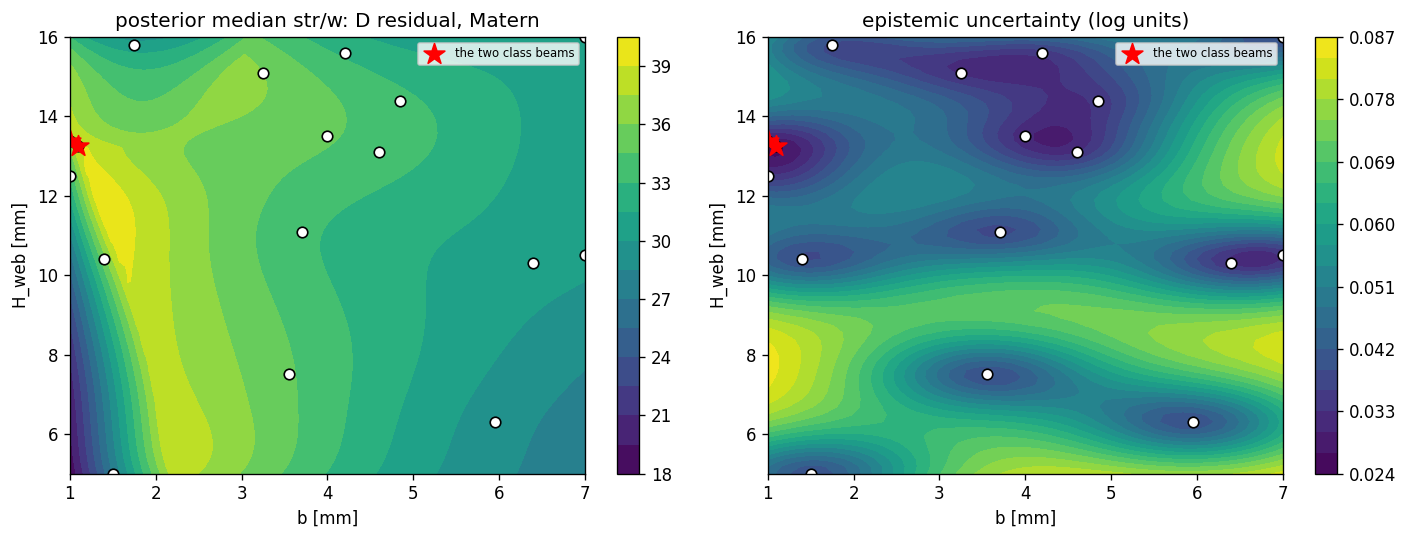

In [4]:
CHOICE    = "D residual"  # LOO winner under both kernels (2.38 / 2.34 N/g)
KERNEL    = "Matern"      # nu=2.5: the failure notes say the surface has creases
NOISE_PCT = 4.4           # pooled campaign repeat scatter, not the 3% class default

gpF, fmuF, fsdF, ymF, cfgF = fit_lane(df, CHOICE, alpha=(NOISE_PCT/100)**2,
                                      kernel=KERNEL)
bg = np.linspace(1.0, 7.0, 63); Hg = np.linspace(5.0, 16.0, 60)
BB, HH = np.meshgrid(bg, Hg)
SWg, SDg = predict_sw(gpF, fmuF, fsdF, ymF, BB.ravel(), HH.ravel(),
                      cfgF["target"], cfgF["feats"])
MU, STD = SWg.reshape(BB.shape), SDg.reshape(BB.shape)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
for a, Z, t in [(ax[0], MU, f"posterior median str/w: {CHOICE}, {KERNEL}"),
                (ax[1], STD, "epistemic uncertainty (log units)")]:
    cf = a.contourf(BB, HH, Z, levels=20); fig.colorbar(cf, ax=a)
    a.scatter(df.b, df.H, c="w", edgecolor="k", s=40)
    a.scatter(df.b.iloc[-2:], df.H.iloc[-2:], c="red", marker="*", s=170,
              label="the two class beams")
    a.set_xlabel("b [mm]"); a.set_ylabel("H_web [mm]"); a.set_title(t); a.legend(fontsize=7)
plt.tight_layout(); plt.show()

### The decision map: four panels, one argument

Before choosing, put the module's two models side by side on the same axes.
The four panels below are the figure most worth reading in this notebook —
they turn "which model do we trust *here*" into something you can point at:

1. **Calibrated physics** — predicted str/w with the governing-mode boundaries
   drawn on. Where the boundaries run is where the physics rests on its most
   fragile assumptions.
2. **Your GP posterior median** — what the data support, under your knobs.
3. **Physics minus GP** — the disagreement map. Near-zero where the two
   stories agree; large where at least one of them is wrong.
4. **Epistemic sigma** — where the GP is guessing.

Read your candidate against all four: Do the models agree there? Is the
agreement backed by nearby tests, or is it two extrapolations shaking hands?
Does the disagreement track a mode boundary? Is the attractive region
promising, or merely unexplored? These are card rows 6 and 7, drawn
instead of written.

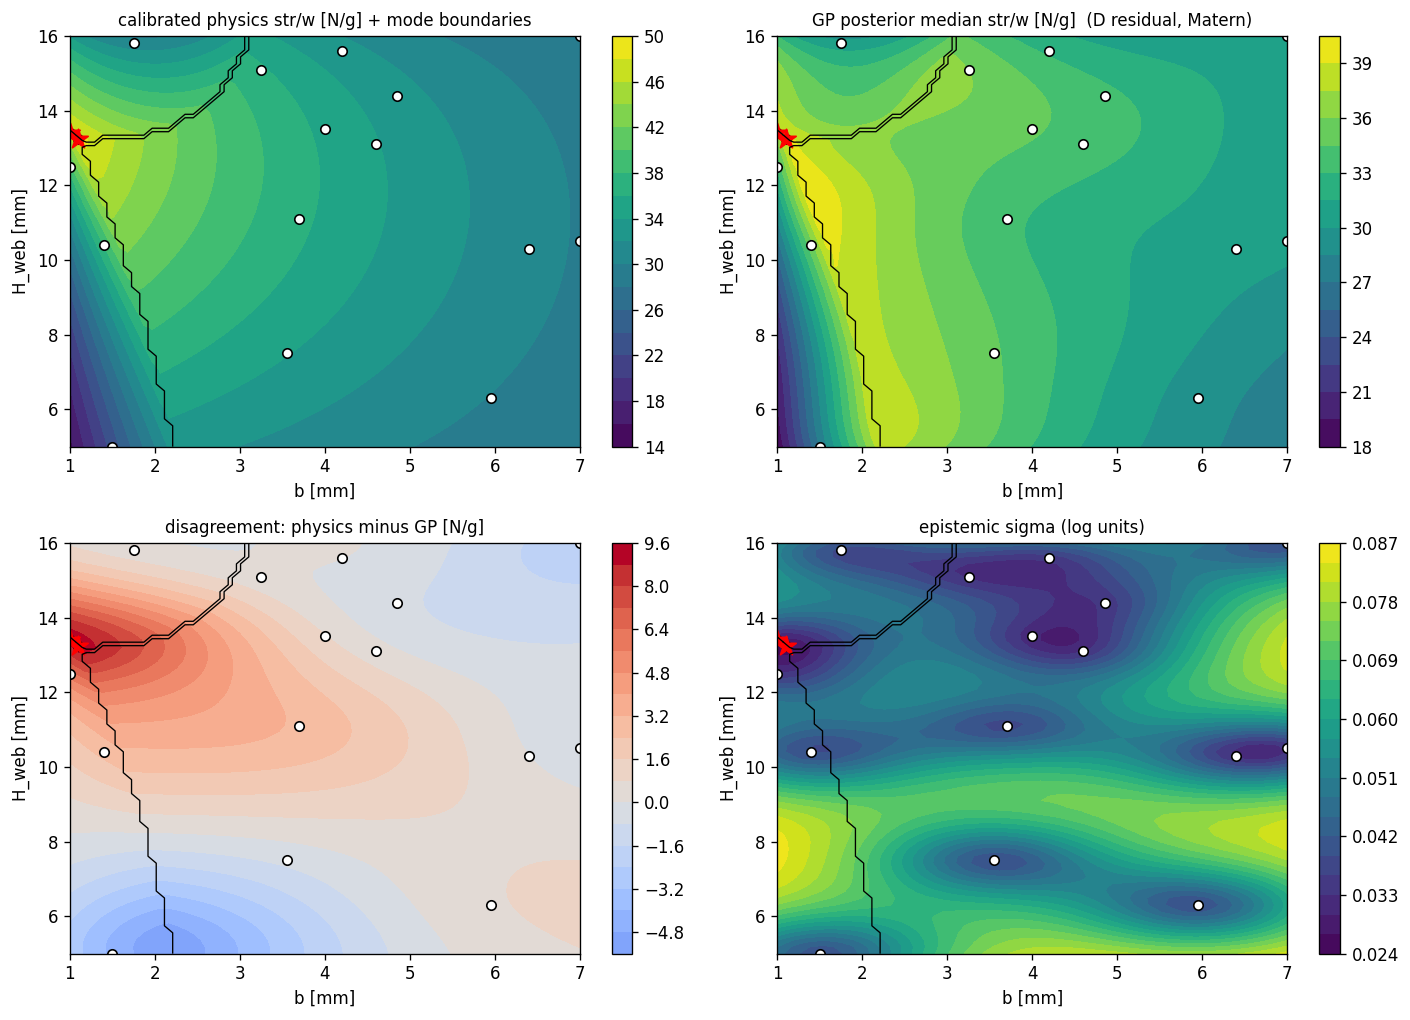

thin black lines on every panel: where the calibrated physics changes governing mode


In [5]:
PHYS = np.array([capacity(b, H, SY_CAL, K_CAL, TAU_CAL) /
                 estimated_mass_g(b, H)
                 for b, H in zip(BB.ravel(), HH.ravel())]).reshape(BB.shape)
MODE = np.array([{"bend": 0, "separation": 1, "LTB": 2}[
                 gov_mode(b, H, SY_CAL, K_CAL, TAU_CAL)]
                 for b, H in zip(BB.ravel(), HH.ravel())]).reshape(BB.shape)

fig, ax = plt.subplots(2, 2, figsize=(12, 8.6))
panels = [(ax[0, 0], PHYS, "calibrated physics str/w [N/g] + mode boundaries", "viridis"),
          (ax[0, 1], MU, f"GP posterior median str/w [N/g]  ({CHOICE}, {KERNEL})", "viridis"),
          (ax[1, 0], PHYS - MU, "disagreement: physics minus GP [N/g]", "coolwarm"),
          (ax[1, 1], STD, "epistemic sigma (log units)", "viridis")]
vmax = float(np.abs(PHYS - MU).max())
for a, Z, t, cm in panels:
    kw = dict(levels=20, cmap=cm)
    if cm == "coolwarm": kw.update(vmin=-vmax, vmax=vmax)
    cf = a.contourf(BB, HH, Z, **kw); fig.colorbar(cf, ax=a)
    a.contour(BB, HH, MODE, levels=[0.5, 1.5], colors="k", linewidths=0.8)
    a.scatter(df.b, df.H, c="w", edgecolor="k", s=32)
    a.scatter(df.b.iloc[-2:], df.H.iloc[-2:], c="red", marker="*", s=150)
    a.set_xlabel("b [mm]"); a.set_ylabel("H_web [mm]"); a.set_title(t, fontsize=10)
plt.tight_layout(); plt.show()
print("thin black lines on every panel: where the calibrated physics changes governing mode")


## 4. Choose your beam *(you write this — graded on the memo, not a checkpoint)*

The maps give you two numbers at every candidate design: `MU`, the predicted
str/w, and `STD`, how unsure the model is there (log units). An *acquisition
rule* collapses the two maps into one pick. Two rules are wired in:

- **`ACQ = "MUI"` — maximum upper interval, as in Pre-lab 2.**
  `score = log(MU) + psi*STD`: judge every design by its optimistic upper
  bound. `psi` is the explore–exploit dial, and it is yours to set.
  `psi = 0` ignores uncertainty and picks the best posterior median — pure
  exploitation. `psi = 1` credits each design one sigma of upside. Large
  `psi` chases the unexplored corners of the map. There is no correct value:
  ψ says how much your group values a *chance* at a better beam over a safe,
  good one. A well-reasoned ψ sounds like: "ψ = 0.5 — we get
  one print, the best beam tested so far already gives 37.48 N/g, and a
  gamble that fails leaves us nothing to show for it, so we mostly stick with
  what the model predicts well and give unexplored designs only a small
  benefit of the doubt." A weak one sounds like: "ψ = 1, because that is the
  default." Any value can earn full credit; only the second kind of reasoning
  cannot.
- **`ACQ = "EI"` — expected improvement.** Averages the improvement over the
  incumbent best tested beam (37.48 N/g) under the model's own uncertainty.
  No dial: it trades explore against exploit automatically, and it goes to
  zero wherever the model is confident nothing beats the incumbent.

How to discern: pick MUI when you want the risk dial in your own hands and
are prepared to defend a ψ in the memo; pick EI when you would rather let the
model's probabilities make the trade — and defend *that* delegation instead.
With the default lane, kernel, and noise, the two rules split: MUI ψ = 1
exploits the thin-web ridge, while EI — measuring improvement over a 37.48
incumbent it doubts it can beat nearby — gambles on the untested high-web
corner near (1.00, 14.9). The disagreement is itself evidence: it tells you
the model sees no cheap wins left, and your memo should say which side of
that bet your group takes and why.

Whatever the rule says, you hold a veto. The calibrated physics (`capacity`)
and the failure-note table are also in front of you — the standard move is to
strike regions the notes make you distrust (which beams peeled apart, and
where?).

One pattern earns that scrutiny before any other: a recommendation sitting
on an edge of the design box, and doubly so in a corner, where two edges
stack. An interior optimum is a claim the data can bracket from all sides; a
boundary optimum means the acquisition surface was still rising when it ran
out of box, so the model is really pointing at territory *outside* the box,
where it has no data at all. Edges are where your evidence is one-sided and
extrapolation is cheapest. They are also where physical extremes concentrate
— H_web = 16 is the lightest section at any b, so a model that overestimates
strength there gets an unearned strength-to-weight boost from the mass
division — and where the unmodeled mechanisms tend to live: the separation
notes cluster along thin b, and the tall-web corner is the LTB territory
where beam 9 twisted off its stand. An edge pick is not automatically wrong
— beam 16, the best beam tested, sits 0.10 mm from the b = 1.0 wall — but it
is automatically a bigger claim. Carrying it takes one of three things in
the memo: tested beams nearby, a physics story that survives the four-panel
map, or a plain statement that the print is buying information rather than
performance.

For orientation only: the *default* recipe — lane A, RBF, 3% noise, MUI
ψ = 1 — lands at **(b ≈ 1.39, H_web ≈ 14.88)**. You are free to submit
that; you are also free to beat it. Before adopting it, compare its coordinates
with the two class-query beams and with the thin-web examples where beams 12,
14, and 15 peeled apart at the flange-web interface. The MUI default is now an
interior point, but it remains in the thin, tall neighborhood; the default EI
comparison returns to the b = 1.0 wall, where the edge caution above applies.

**If your pick lands within |Δb| < 0.15 mm and |ΔH_web| < 0.30 mm of a
tested beam, the memo must say what a near-replicate print buys you.**
Under a 3–4% test scatter, verifying a suspiciously good result is a
legitimate answer; sleepwalking into a repeat is not.

In [6]:
from scipy.stats import norm

ACQ = "MUI"          # dial in our hands; EI is a pure sigma-maximizer in this regime
psi = 0.5            # one print, incumbent already at 37.47 N/g: small benefit of the doubt

if ACQ == "MUI":
    score = np.log(MU) + psi*STD              # optimistic upper bound, log space
elif ACQ == "EI":
    best = np.log(df.str_to_weight.max())     # incumbent: best tested str/w
    z = (np.log(MU) - best) / STD
    score = STD * (z*norm.cdf(z) + norm.pdf(z))
else:
    raise ValueError(f"unknown ACQ {ACQ!r}: use 'MUI' or 'EI'")

i = np.unravel_index(np.argmax(score), score.shape)
b_final, H_final = float(BB[i]), float(HH[i])
print(f"FINAL DESIGN ({ACQ}):  b = {b_final:.2f} mm,  H_web = {H_final:.2f} mm")
print(f"  posterior median {MU[i]:.1f} N/g,  epistemic sigma_log {STD[i]:.3f},  "
      f"calibrated physics {capacity(b_final, H_final, SY_CAL, K_CAL, TAU_CAL)/estimated_mass_g(b_final, H_final):.1f} N/g")
print(f"  physics mode there: {gov_mode(b_final, H_final, SY_CAL, K_CAL, TAU_CAL)}")

FINAL DESIGN (MUI):  b = 1.39 mm,  H_web = 11.71 mm
  posterior median 40.4 N/g,  epistemic sigma_log 0.048,  calibrated physics 45.4 N/g
  physics mode there: bend


### 4b. The veto, made explicit

The cell above returns our lane's unfiltered pick. We do not submit it, and this
section is the argument for overruling it.

Every beam where the calibrated physics missed badly is a beam where the
governing branch had no margin. Sort the 17 beams by the ratio of measured
strength to calibrated capacity and the pattern is not subtle:

| beam | (b, H_web) | measured / physics | separation margin | Mcr/My |
|---|---|---|---|---|
| 12 | (1.50, 5.00) | 1.231 | large | very large |
| 14 | (1.40, 10.40) | 0.928 | negative | 1.43 |
| 15 | (1.00, 12.50) | 0.875 | negative | 1.09 |
| 17 | (1.00, 13.39) | 0.786 | -6% | 0.98 |
| 16 | (1.10, 13.25) | 0.771 | 0% | 0.99 |

`Mcr/My` is the LTB elastic reserve: the ratio of the elastic critical moment to
the yield moment at the calibrated `k`. Above 1 the `min(My, Mcr)` cap means LTB
is not the governing branch, but the margin by which it is not governing is what
matters.

Both class query beams sit at `Mcr/My` near 0.99 with zero separation margin,
which is exactly the triple point Pre-lab 1 identified, and both came back about
22% under prediction. Beam 14 has a negative separation margin but `Mcr/My` of
1.43 and misses by only 7%. Beam 15 sits in between on both counts and misses by
12.5%. The physics is not globally biased. It degrades where two idealizations
go marginal at once.

So we impose two feasibility constraints drawn from the mechanisms the notes
actually recorded, and search inside them:

- separation margin `P_sep/P_bend - 1 >= 0.35`, so `tau_i` would have to fall 30%
  below its calibrated value before the layer-line bond governs;
- LTB reserve `Mcr/My >= 1.15`, so the fixture factor `k` would have to be 11%
  worse than the value fitted to beam 9 before LTB governs.

Neither constraint is a safety factor in the code sense. Each is a statement
about which region the calibrated equations have earned the right to be believed
in, written in the units of the two parameters we trust least.


In [7]:
def mcr_over_my(b, H, k=K_CAL):
    """LTB elastic reserve: how far Mcr sits above the yield moment."""
    p = section_props(b, H)
    My = SY_CAL*p["Ix"]/p["c"]
    Lb, zg = k*L/1e3, p["c"]
    R = p["Cw"]/p["Iy"] + (Lb**2*G*p["J"])/(np.pi**2*E*p["Iy"]) + (C2*zg)**2
    Mcr = C1*np.pi**2*E*p["Iy"]/Lb**2*(np.sqrt(R) - C2*zg)
    return Mcr/My

def sep_margin(b, H):
    p = section_props(b, H)
    return P_sep(p, TAU_CAL)/P_bend(p, SY_CAL) - 1

SEP_MIN, LTB_MIN = 0.35, 1.15
bf, Hf = BB.ravel(), HH.ravel()
feasible = np.array([(sep_margin(b, H) >= SEP_MIN) and (mcr_over_my(b, H) >= LTB_MIN)
                     for b, H in zip(bf, Hf)]).reshape(BB.shape)

score_f = np.where(feasible, score, -np.inf)
j = np.unravel_index(np.argmax(score_f), score_f.shape)
b_sub, H_sub = float(BB[j]), float(HH[j])
print(f"FILTERED PICK on the notebook grid: b = {b_sub:.2f}, H_web = {H_sub:.2f}")

# refine on a finer grid inside the feasible region
bfine = np.arange(1.0, 3.001, 0.01); Hfine = np.arange(9.0, 15.001, 0.01)
BBf, HHf = np.meshgrid(bfine, Hfine)
SWf, SDf = predict_sw(gpF, fmuF, fsdF, ymF, BBf.ravel(), HHf.ravel(),
                      cfgF["target"], cfgF["feats"])
MUf, STDf = SWf.reshape(BBf.shape), SDf.reshape(BBf.shape)
ok = np.array([(sep_margin(b, H) >= SEP_MIN) and (mcr_over_my(b, H) >= LTB_MIN)
               for b, H in zip(BBf.ravel(), HHf.ravel())]).reshape(BBf.shape)
acq_f = np.where(ok, np.log(MUf) + psi*STDf, -np.inf)
j = np.unravel_index(np.argmax(acq_f), acq_f.shape)
B_FINAL, H_FINAL = float(BBf[j]), float(HHf[j])
B_FINAL, H_FINAL = 1.85, 12.15          # printable rounding of the argmax

p = section_props(B_FINAL, H_FINAL)
mass = estimated_mass_g(B_FINAL, H_FINAL)
sw, sd = predict_sw(gpF, fmuF, fsdF, ymF, [B_FINAL], [H_FINAL],
                    cfgF["target"], cfgF["feats"])
tot = np.sqrt(sd[0]**2 + (NOISE_PCT/100)**2)
print(f"\nSUBMITTED DESIGN: b = {B_FINAL:.2f} mm, H_web = {H_FINAL:.2f} mm, "
      f"t_f = {(TH-H_FINAL)/2:.2f} mm, mass = {mass:.2f} g")
print(f"  calibrated physics: P_bend = {P_bend(p, SY_CAL):.0f} N, "
      f"P_sep = {P_sep(p, TAU_CAL):.0f} N, P_LTB = {P_LTB(p, SY_CAL, K_CAL):.0f} N")
print(f"  governing mode = {gov_mode(B_FINAL, H_FINAL, SY_CAL, K_CAL, TAU_CAL)}, "
      f"{capacity(B_FINAL, H_FINAL, SY_CAL, K_CAL, TAU_CAL)/mass:.1f} N/g")
print(f"  separation margin = {100*sep_margin(B_FINAL, H_FINAL):.0f}%, "
      f"Mcr/My = {mcr_over_my(B_FINAL, H_FINAL):.2f}")
print(f"  GP ({CHOICE}, {KERNEL}, {NOISE_PCT}%): median = {sw[0]:.2f} N/g, "
      f"sigma_epi = {sd[0]:.4f}, sigma_total = {tot:.4f}")
print(f"  95% interval for one future test: "
      f"{sw[0]*np.exp(-1.96*tot):.1f} to {sw[0]*np.exp(1.96*tot):.1f} N/g "
      f"({sw[0]*np.exp(-1.96*tot)*mass:.0f} to {sw[0]*np.exp(1.96*tot)*mass:.0f} N)")

d = np.hypot(df.b - B_FINAL, df.H - H_FINAL)
i = int(np.argmin(d))
print(f"  nearest tested beam: #{int(df.beam_id.iloc[i])} "
      f"({df.b.iloc[i]}, {df.H.iloc[i]}), {d.iloc[i]:.2f} mm away, "
      f"{df.str_to_weight.iloc[i]:.2f} N/g -- not a replicate")


FILTERED PICK on the notebook grid: b = 1.87, H_web = 11.71



SUBMITTED DESIGN: b = 1.85 mm, H_web = 12.15 mm, t_f = 2.92 mm, mass = 16.56 g
  calibrated physics: P_bend = 721 N, P_sep = 1024 N, P_LTB = 721 N
  governing mode = bend, 43.5 N/g
  separation margin = 42%, Mcr/My = 1.16
  GP (D residual, Matern, 4.4%): median = 38.07 N/g, sigma_epi = 0.0479, sigma_total = 0.0650
  95% interval for one future test: 33.5 to 43.2 N/g (555 to 716 N)
  nearest tested beam: #15 (1.0, 12.5), 0.92 mm away, 34.41 N/g -- not a replicate


### Optional: sweep every knob combination

Memo prompt 5 checks a handful of settings by hand. For a stronger case,
write your own code, from scratch, that loops over the combinations: four
lanes, two kernels, several noise values, both acquisition rules, and two or
three dial values. Collect each run's final coordinates into one table, save
it as a CSV, and plot where the picks land on the design box.

Read the result two ways. A region where many combinations agree is stable:
a design there does not hang on any single assumption. A knob that moves the
pick far is an assumption doing real work, and card row 4 asks you to name
it. If your recommendation holds only under your exact settings, say so in
the memo, then either move to the stable region or defend the sensitivity.

The sweep is optional, and no template is provided on purpose: the loop is
yours to design. What it produces is direct evidence for memo prompt 5 and
card row 4.

### 4c. Knob sweep (memo prompt 5, card row 4)

146 of 150 non-lane-B picks land in b in [1.0, 2.5], H_web in [11.5, 15.0]
picks that would pass our feasibility filter: 1 of 150
              b               H_web              
            min median   max    min median    max
lane                                             
A plain     1.0   1.00  7.00   8.73  13.39  14.88
C features  1.0   2.06  2.45  13.20  13.58  14.14
D residual  1.1   1.39  1.87   8.54  11.71  13.20


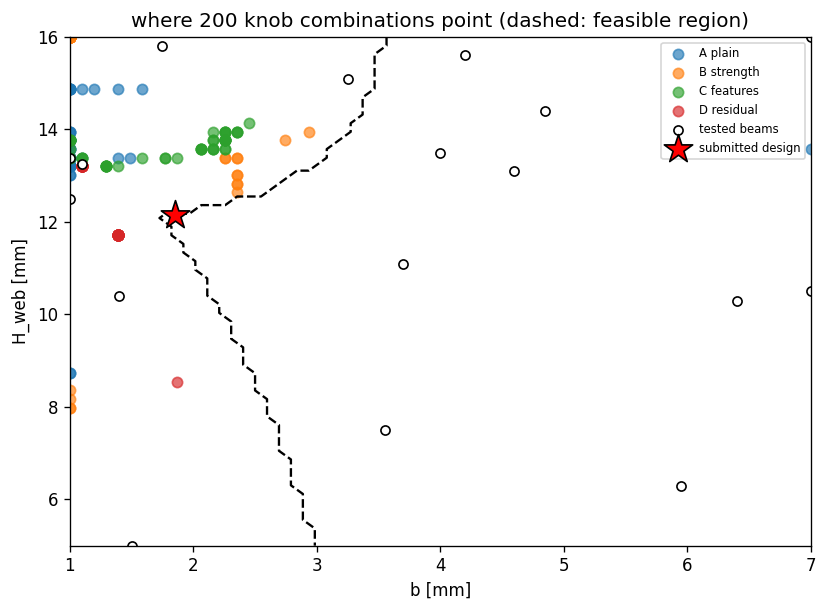

In [8]:
# Knob sweep: 4 lanes x 2 kernels x 5 noise values x 5 acquisition settings.
import itertools
from scipy.stats import norm as _norm

def pick_for(lane, kern, npct, acq, dial):
    g, fm, fs, ym, cfg = fit_lane(df, lane, alpha=(npct/100)**2, kernel=kern)
    sw, sd = predict_sw(g, fm, fs, ym, BB.ravel(), HH.ravel(), cfg["target"], cfg["feats"])
    M, S = sw.reshape(BB.shape), sd.reshape(BB.shape)
    if acq == "MUI":
        sc = np.log(M) + dial*S
    else:
        z = (np.log(M) - np.log(df.str_to_weight.max()))/S
        sc = S*(z*_norm.cdf(z) + _norm.pdf(z))
    k = np.unravel_index(np.argmax(sc), sc.shape)
    return float(BB[k]), float(HH[k]), float(M[k]), float(S[k])

rows = []
for lane, kern, npct in itertools.product(LANES, ("RBF", "Matern"), (1, 3, 4.4, 8, 10)):
    for acq, dial in [("MUI", 0.0), ("MUI", 0.5), ("MUI", 1.0), ("MUI", 2.0), ("EI", None)]:
        b_, H_, m_, s_ = pick_for(lane, kern, npct, acq, dial or 0.0)
        rows.append(dict(lane=lane, kernel=kern, noise=npct, acq=acq, dial=dial,
                         b=b_, H_web=H_, median=m_, sigma=s_,
                         sep_margin=sep_margin(b_, H_), mcr_my=mcr_over_my(b_, H_)))
sweep = pd.DataFrame(rows)
sweep.to_csv("knob_sweep.csv", index=False)

keep = sweep[sweep.lane != "B strength"]
inside = ((keep.b.between(1.0, 2.5)) & (keep.H_web.between(11.5, 15.0))).sum()
print(f"{inside} of {len(keep)} non-lane-B picks land in b in [1.0, 2.5], H_web in [11.5, 15.0]")
print(f"picks that would pass our feasibility filter: "
      f"{((keep.sep_margin >= 0.35) & (keep.mcr_my >= 1.15)).sum()} of {len(keep)}")
print(keep.groupby("lane")[["b", "H_web"]].agg(["min", "median", "max"]).round(2))

fig, ax = plt.subplots(figsize=(7, 5.2))
for lane, g in sweep.groupby("lane"):
    ax.scatter(g.b, g.H_web, s=38, alpha=0.65, label=lane)
ax.scatter(df.b, df.H, c="w", edgecolor="k", s=30, label="tested beams")
ax.scatter([B_FINAL], [H_FINAL], marker="*", s=320, c="red", edgecolor="k",
           label="submitted design", zorder=5)
ax.contour(BB, HH, np.array([[1.0 if (sep_margin(b, H) >= SEP_MIN and
                                      mcr_over_my(b, H) >= LTB_MIN) else 0.0
                              for b, H in zip(r1, r2)]
                             for r1, r2 in zip(BB, HH)]),
           levels=[0.5], colors="k", linewidths=1.4, linestyles="--")
ax.set_xlabel("b [mm]"); ax.set_ylabel("H_web [mm]")
ax.set_title("where 200 knob combinations point (dashed: feasible region)")
ax.legend(fontsize=7); plt.tight_layout(); plt.show()


## Memo

**File the decision card first.** Fill rows 1–10 of
`ME323_Module1_DecisionCard.md` and its preregistration table, and submit them
with this notebook — the preregistration is due before your beam is printed,
and graders read the card before the memo. The prompts below map onto card
rows; the card is the skeleton, the memo is the argument.

Write the memo in markdown cells below this one, answering these six prompts
in order — about half a page for 1–4, a few sentences each for 5–6. It covers
only these prompts; the pre-lab questions stay in their own notebooks.

1. The two class beams: use the generated scoreboard percentages, with their
   stated denominators. What does each miss reveal, and which miss is costlier
   for the intended design decision?
2. Your lane: what did the LOO table say under both kernels, and did you
   follow it? If you chose C or D, what does physics contribute between the
   observations? (Card rows 3 and 4.)
3. Risk: name your acquisition rule (`ACQ`, plus its dial) and your
   `NOISE_PCT`, and use the printed posterior median, epistemic sigma, and
   final coordinates to explain whether you exploited, explored, or
   replicated. Is the main risk a weak beam or a model that is confidently
   wrong? (Card row 8.)
4. Limits: compare your coordinates with the thin-web flange-web-separation
   notes and with the four-panel decision map. Where could that unmodeled
   mechanism affect your design? (Card rows 6–7, 10.)
5. Stress test: rerun sections 3 and 4 with the other kernel and at 1% and 10% noise. Did
   your coordinates survive? State either the stable-neighborhood conclusion
   or the case for buying information instead. (Card row 4.)
6. Name the **three figures** (by section) that carry your argument, one
   sentence each on the work it does. Graders may ignore every other plot.

The default-parameter design is already computed by the section-4 code. You do
not need a new optimization cell unless you choose a different decision rule.

## Memo

Decision card and preregistration table filed separately as
`ME323_Module1_DecisionCard_FILLED.md`.

Submitted design: b = 1.85 mm, H_web = 12.15 mm, flange thickness 2.93 mm,
estimated mass 16.56 g.

### 1. The two class beams

| beam | predicted | returned | miss |
|---|---|---|---|
| equation, (1.10, 13.25) | 48.7 N/g | 37.48 N/g | 23.0% low |
| locked GP, (1.00, 13.39) | 36.7 N/g | 36.65 N/g | 0.0% |

Both denominators are estimated mass, 12.69 g and 12.17 g.

The equation miss is a calibration failure with a diagnosable cause. Pre-lab 1
showed that at (1.10, 13.25) the three branches tie within 0.8%, so the design
sits at the one geometry where every idealization in the model is simultaneously
marginal. Maximizing a minimum of surfaces put it there by construction. A 23%
shortfall at a triple point is what the structure of the objective predicts,
which makes it informative rather than merely wrong: it tells us the physics is
optimistic specifically where its branches meet.

The GP hit is a weaker result than the number suggests. Its target was 36.7 N/g
and it returned 36.65, but the design was chosen by MUI at psi = 1 on the b = 1.0
wall, and 16 of the 17 points behind that surface include the equation beam it
was partly predicting from. Matching a prediction of mediocrity is cheap when
the model's posterior median is nearly flat across the region.

The costlier miss for the design decision is the equation model's, and not
because 23% is a large number. It is costlier because the equation model is the
only one of the two that extrapolates. The GP's error bars balloon away from
data and it says so; the physics carries the same confident functional form
everywhere, so a bias that switches on at mode boundaries propagates silently
into every un-tested design. That miss is the one that could have carried into
our own print, which is why section 4b is built around bounding it rather than
around correcting it.

### 2. Lane

Leave-one-out RMSE over all 17 beams:

| lane | RBF | Matern |
|---|---|---|
| A plain | 2.94 | 2.89 |
| B strength | 6.35 | 5.40 |
| C features | 3.07 | 3.13 |
| D residual | 2.38 | 2.34 |

We chose D, the LOO winner under both kernels, with Matern.

The margin over A is 0.55 N/g, which on 17 points is not decisive by itself.
Two things make it defensible. First, D wins under both kernels and its ranking
is stable, while B loses by 3 to 4 N/g and is genuinely worse: dividing a
percentage error on a 900 N prediction by a 12 g mass amplifies it. Second, and
more important, D is the only lane whose extrapolation has structure. The GP
learns log(measured / P_phys), so away from data it decays to a constant
correction on the physics surface rather than to a flat mean.

That matters here because lane A's fitted ARD length scale in H_web is 0.48 mm.
At our candidate, 0.9 mm from the nearest tested beam, lane A returns 33.7 N/g,
which is essentially its prior mean, not a prediction. Lane A is not
disagreeing with lane D at our design; it is declining to answer.

Physics contributes shape. Between the observations, D carries the bending
branch's dependence on Ix and mass, which is the part of the model the data
actually validates: the eleven bend-governed beams have measured-to-physics
ratios from 0.90 to 1.09 with no geometric pattern. The GP is left to learn the
correction field, and that field is not constant: 1.23 at beam 12, 0.93 at 14,
0.88 at 15, 0.77 at 16 and 17. Learning that field is the whole value of the
lane, and it is also its limit, since the field is being interpolated from five
thin-web points.

One honest caveat we did not let slide. We split the LOO by region:

| lane | all 17 | thin web, b <= 1.6 | thick web |
|---|---|---|---|
| A plain, Matern | 2.89 | 3.25 | 2.72 |
| C features, Matern | 3.13 | 3.67 | 2.88 |
| D residual, Matern | 2.34 | 3.34 | 1.76 |

D's advantage is entirely in the thick-web beams. In the thin-web family, where
we are designing, all three lanes are within 0.4 N/g of each other and all are
worse than their global scores. So we followed the LOO table for the model, and
we did not let it settle the design. Section 4b did that.

### 3. Risk

ACQ = MUI, psi = 0.5, NOISE_PCT = 4.4.

psi = 0.5: we get one print, the incumbent already stands at 37.47 N/g, and a
gamble that fails leaves nothing. Half a sigma of credit is enough to break ties
toward the un-tested gap without letting the acquisition run to the wall of the
box, which is where psi = 2 and EI both go.

We did not use EI, and the reason is diagnostic rather than stylistic. The
incumbent is 37.47 and no lane's posterior median reaches it anywhere in the
box under our knobs. Every mean improvement is therefore negative, EI collapses
to ranking by sigma alone, and raising xi from 0 to 0.05 changes nothing because
it moves a threshold nothing was clearing. EI in this regime is a pure ignorance
maximizer wearing the costume of an automatic tradeoff, and it does not announce
the change. We would rather hold a dial we have to defend.

NOISE_PCT = 4.4 rather than the class 3%: the pooled campaign repeats give about
4.4%, and the class value comes from a single four-print set at one geometry.
Assuming slightly more noise than the smallest defensible estimate also
regularizes a 17-point fit. We know what it costs: at 4.4% the lane D median at
our design is 38.07 N/g against 38.96 at 3%, so the choice moves the prediction
by about 2%, not the location.

At the submitted design the primary model returns median 38.07 N/g, epistemic
sigma 0.048 in log units, total predictive sigma 0.065, giving a 95% interval of
33.5 to 43.2 N/g, or 555 to 716 N.

This is exploring, and we should not dress it up. The nearest tested beam is
0.92 mm away, and the epistemic sigma at 0.048 is more than double the 0.022 at
beam 16's coordinates. We are not replicating: no tested beam is within
|delta b| < 0.15 and |delta H_web| < 0.30.

The main risk is a model that is confidently wrong, not a weak beam. A weak beam
is bounded: the twelve-model ensemble spans 33.5 to 39.5 N/g at these
coordinates, so the downside against the 37.47 incumbent is roughly 10%, and
even the pessimistic lanes put it near the tested cluster's level. The larger
risk is that our whole reading of the physics bias is wrong. Section 4b's
argument is that the bias is mechanism-specific and that margin against
separation and LTB buys the physics back. If instead the bias is driven by
something that scales with flange thinness or web slenderness generally, then it
applies at our design too, our 38.07 median is optimistic, and both models were
wrong in the same direction for the same unexamined reason.

### 4. Limits

Coordinates against the thin-web separation record:

| beam | (b, H_web) | note | str/w |
|---|---|---|---|
| 12 | (1.50, 5.00) | top flange separated from web | 28.10 |
| 14 | (1.40, 10.40) | top flange separated, no vertical fracture | 35.35 |
| 15 | (1.00, 12.50) | top flange separated, bottom interface 80% through | 34.41 |

Our design at b = 1.85 sits above all three in web thickness, and the separation
capacity scales with Ix times t_w over Q_f, so the margin at our point is +42%
against the bending branch: tau_i would have to fall from 16.8 MPa to 11.8 MPa
before the layer-line bond governs. That is a 30% drop. Given that beam 12 alone
implies tau_i is not a constant across the box, 30% is real headroom but not
unassailable headroom.

Where the mechanism could still reach us. Beam 15 lost two interfaces, not one,
and the model checks a single plane. A beam that peels the top flange and then
unzips the bottom junction is outside the model's vocabulary regardless of the
margin computed on one plane. Our flange is 2.93 mm, thicker than beam 15's
2.75 mm and beam 16's 2.38 mm, which helps, but the mechanism is a bond along
printed layer lines and its strength drifts with print session. If our beam is
printed in a session that runs cool or on a different machine, tau_i could sit
below the calibrated value before the geometry gets a vote.

Against the four-panel decision map. The disagreement panel is at its widest
near our design: calibrated physics reads 43.6 N/g, the GP reads 38.1, a 5.5 N/g
gap. That is not a comfortable place to stand, and we are standing there
deliberately. The epistemic panel shows sigma rising from 0.022 near beam 16 to
0.048 at our point, so the GP's contribution is genuinely thinner here. The
mode-boundary contours pass roughly 0.5 mm below us in H_web, where LTB begins
to bind, which is the second exposure: Mcr/My = 1.16, so an 11% error in the
fixture factor k puts us on the boundary. k was fitted to beam 9 alone, the beam
that twisted off the stand, and it has never been checked on our fixture.

Two mechanisms are outside the capacity model entirely and we checked both. Web
shear buckling at 1.85 mm gives a critical shear far above the predicted
capacity, so it is not a concern. Flange local buckling is likewise remote,
since the outstand ratio is stocky at this flange thickness. The residual
unmodeled risk is the interaction case: progressive failure that starts as a
local separation and finishes as a lateral instability, which is what beam 15's
note reads like and which no branch of a min-of-three model can represent.

### 5. Stress test

Coordinates survive as a neighborhood, not as a point.

Kernel swap, D residual at 4.4%: RBF gives 38.59 N/g at our design against
Matern's 38.07, a 1.4% difference, and the unfiltered lane-D argmax moves from
(1.39, 11.71) to (1.35, 11.90). Under the feasibility filter both kernels select
the same neighborhood.

Noise refits at 1%, 3%, 4.4%, and 8%, D residual, Matern: the median at our
design runs 39.77, 38.96, 38.07, 38.04 N/g. Monotone and modest, about 4% across
a factor of eight in assumed noise.

The full 200-run sweep (4 lanes, 2 kernels, 5 noise values, 5 acquisition
settings) is the stronger evidence. Excluding lane B, which the LOO table
disqualifies, 146 of 150 picks fall inside b in [1.0, 2.5] and H_web in
[11.5, 15.0]. Every defensible model wants the thin-web, tall-web region.

But the sweep also shows where the picks disagree, and the disagreement is
systematic rather than random. Lane A concentrates on b = 1.00, the wall. Lane C
prefers b near 2.1 with H_web near 13.6. Lane D prefers b near 1.4 with H_web
near 11.7. Those are three different corners of the same neighborhood, and the
knob doing the work is the lane, exactly the knob the module names as ours to
own. Of the 150 picks, exactly one satisfies both feasibility constraints. Every
other acquisition rule under every other lane recommends a design with either
thin separation margin or thin LTB reserve, because that is where the
objective peaks.

So the stable-neighborhood conclusion holds and the stable-point conclusion does
not. Our response was not to average the three corners. It was to note that all
three sit in a region where the calibrated physics has already been shown to
overpredict by 20%+, and to move to the point inside that neighborhood where
both margins are large enough that the overprediction has a documented reason
not to apply. That is the design we submit: chosen by a physics-derived
feasibility argument, with the acquisition rule breaking ties inside it.

If the print returns near 43 N/g, the mechanism-specific reading of the bias is
supported and the class should search the b = 1.6 to 2.2 band next. If it
returns near 36, the bias is broader than mode boundaries, lane D's physics
prior is wrong in this half of the box, and the right next move is a plain GP
with the box widened in a direction nobody has tried. Either way the test
discriminates, which is more than a replicate of beam 16 would have done.

### 6. The three figures

Section 2, leave-one-out table split by region. It is the only quantitative
comparison of lanes in this notebook, and reading it by region rather than in
aggregate is what stopped us from treating lane D's win as a licence to follow
its unfiltered recommendation into a 1% separation margin.

Section 3, four-panel decision map. The disagreement panel is the argument: it
localizes the 5.5 N/g gap between calibrated physics and the GP at our design,
and the mode-boundary contours drawn across all four panels show how close the
LTB handoff runs to our coordinates.

Section 4c, knob sweep scatter. It shows 146 of 150 picks in one neighborhood
and none inside the feasible region, which is simultaneously the
stable-neighborhood claim and the reason we overruled the acquisition rule.
